# Controlled hyperparameter tuning

Feature engineering didn't help (15 features stayed the best representation), so this notebook asks a different question: can reasonable hyperparameter choices for Logistic Regression and CatBoost improve out-of-time performance, on the same 15 features, without ever looking at the test set during the search? Random Forest is not tuned, it already performed clearly worse and isn't a priority here.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from sklearn.metrics import (average_precision_score, roc_auc_score, precision_score,
                              recall_score, f1_score, accuracy_score, confusion_matrix,
                              precision_recall_curve, roc_curve)

pred = pd.read_csv("../outputs/prediction_events_current_v1.csv",
                    parse_dates=["inspectionDate", "prev_inspectionDate"], low_memory=False)
long = pd.read_csv("../outputs/inspection_level_longitudinal.csv",
                    parse_dates=["inspectionDate"], low_memory=False)
long = long.sort_values(["estId", "inspectionDate"]).reset_index(drop=True)
print("prediction rows:", len(pred))

prediction rows: 69766


## Rebuild the 730-day features and the 15-feature set

Same construction as the previous notebooks, no new feature families.

In [2]:
long["is_non_pass"] = long["inspectionStatus"].isin(["Conditional Pass", "Closed"]).astype(int)

def rolling_window(g, days, prefix):
    g = g.reset_index()
    dates = g["inspectionDate"].values.astype("datetime64[D]")
    total_infr = g["n_infractions"].to_numpy()
    crucial = g["n_crucial"].to_numpy()
    non_pass = g["is_non_pass"].to_numpy()

    cs_infr = np.concatenate([[0], np.cumsum(total_infr)])
    cs_crucial = np.concatenate([[0], np.cumsum(crucial)])
    cs_nonpass = np.concatenate([[0], np.cumsum(non_pass)])

    lower_edge = dates - np.timedelta64(days, "D")
    low_idx = np.searchsorted(dates, lower_edge, side="left")

    idx_arr = np.arange(len(g))
    return pd.DataFrame({
        "orig_index": g["index"],
        f"{prefix}_n_inspections": idx_arr - low_idx,
        f"{prefix}_n_non_pass": cs_nonpass[idx_arr] - cs_nonpass[low_idx],
        f"{prefix}_total_infractions": cs_infr[idx_arr] - cs_infr[low_idx],
        f"{prefix}_crucial_infractions": cs_crucial[idx_arr] - cs_crucial[low_idx],
    })

rolled_730 = long.groupby("estId", group_keys=False).apply(rolling_window, days=730, prefix="prior_730d").set_index("orig_index")
long_feat = long.join(rolled_730)

hist_730 = long_feat[["estId", "inspectionDate", "prior_730d_n_inspections", "prior_730d_n_non_pass",
                       "prior_730d_total_infractions", "prior_730d_crucial_infractions"]]

df = pred.merge(hist_730, on=["estId", "inspectionDate"], how="left")
assert len(df) == len(pred)
assert df["prior_730d_n_inspections"].isna().sum() == 0

BASE = ["days_since_previous_inspection", "prev_non_pass", "prev_total_infractions",
        "prev_minor", "prev_significant", "prev_crucial", "n_inspections_seen_so_far"]
HIST365 = ["prior_365d_n_inspections", "prior_365d_n_non_pass",
           "prior_365d_total_infractions", "prior_365d_crucial_infractions"]
HIST730 = ["prior_730d_n_inspections", "prior_730d_n_non_pass",
           "prior_730d_total_infractions", "prior_730d_crucial_infractions"]

FEATURES = BASE + HIST365 + HIST730
assert len(FEATURES) == 15

identifier_cols = {"estId", "oldEstId", "_id", "unique_id"}
outcome_cols = {"OutcomeDate", "OutcomeDesc", "amountFined", "inspectionStatus"}
assert identifier_cols.isdisjoint(FEATURES)
assert outcome_cols.isdisjoint(FEATURES)

## Strict temporal split, same as the earlier notebooks

In [3]:
df = df.sort_values("inspectionDate").reset_index(drop=True)

unique_dates = np.sort(df["inspectionDate"].unique())
n_dates = len(unique_dates)
train_cut = unique_dates[int(n_dates * 0.70)]
val_cut = unique_dates[int(n_dates * 0.85)]

train = df[df["inspectionDate"] < train_cut].copy()
val = df[(df["inspectionDate"] >= train_cut) & (df["inspectionDate"] < val_cut)].copy()
test = df[df["inspectionDate"] >= val_cut].copy()

assert len(train) == 45334 and len(val) == 11740 and len(test) == 12692
assert train["inspectionDate"].max() < val["inspectionDate"].min()
assert val["inspectionDate"].max() < test["inspectionDate"].min()
print("split matches earlier notebooks exactly")

X_train, y_train = train[FEATURES], train["target"]
X_val, y_val = val[FEATURES], val["target"]
X_test, y_test = test[FEATURES], test["target"]

split matches earlier notebooks exactly


## Logistic Regression search (train + validation only)

Tuning only `C`, over a small fixed candidate set. No test predictions are made in this cell, only `X_train`/`y_train`/`X_val`/`y_val` are touched.

In [4]:
lr_results = []
for C in [0.01, 0.1, 1.0, 10.0, 100.0]:
    pipe = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
        ("clf", LogisticRegression(C=C, class_weight="balanced", max_iter=1000, random_state=42)),
    ])
    pipe.fit(X_train, y_train)
    val_proba = pipe.predict_proba(X_val)[:, 1]
    lr_results.append({
        "model": "logistic_regression",
        "configuration": f"C={C}",
        "val_pr_auc": average_precision_score(y_val, val_proba),
        "val_roc_auc": roc_auc_score(y_val, val_proba),
    })

lr_search_df = pd.DataFrame(lr_results)
lr_search_df

,model,configuration,val_pr_auc,val_roc_auc
0,logistic_regression,C=0.01,0.162496,0.729321
1,logistic_regression,C=0.1,0.163071,0.729777
2,logistic_regression,C=1.0,0.163157,0.729785
3,logistic_regression,C=10.0,0.163152,0.729784
4,logistic_regression,C=100.0,0.163148,0.729784


In [5]:
best_lr = lr_search_df.sort_values(["val_pr_auc", "val_roc_auc"], ascending=[False, False]).iloc[0]
print("best Logistic Regression configuration:", best_lr["configuration"], "val PR-AUC:", round(best_lr["val_pr_auc"], 4))

best Logistic Regression configuration: C=1.0 val PR-AUC: 0.1632


## CatBoost search (train + validation only)

Eight fixed configurations, varying depth, iterations, and learning rate. Class weighting, loss function, and random seed are held fixed across all of them. Again, no test data is touched here.

In [6]:
cb_configs = [
    {"iterations": 300, "depth": 4, "learning_rate": 0.05},
    {"iterations": 500, "depth": 4, "learning_rate": 0.05},
    {"iterations": 800, "depth": 4, "learning_rate": 0.05},
    {"iterations": 300, "depth": 6, "learning_rate": 0.05},
    {"iterations": 500, "depth": 6, "learning_rate": 0.05},
    {"iterations": 800, "depth": 6, "learning_rate": 0.05},
    {"iterations": 500, "depth": 8, "learning_rate": 0.03},
    {"iterations": 800, "depth": 8, "learning_rate": 0.03},
]

cb_results = []
for cfg in cb_configs:
    model = CatBoostClassifier(
        iterations=cfg["iterations"], depth=cfg["depth"], learning_rate=cfg["learning_rate"],
        loss_function="Logloss", auto_class_weights="Balanced", random_seed=42, verbose=False,
    )
    model.fit(X_train, y_train)
    val_proba = model.predict_proba(X_val)[:, 1]
    label = f"iterations={cfg['iterations']},depth={cfg['depth']},lr={cfg['learning_rate']}"
    cb_results.append({
        "model": "catboost",
        "configuration": label,
        "val_pr_auc": average_precision_score(y_val, val_proba),
        "val_roc_auc": roc_auc_score(y_val, val_proba),
    })

cb_search_df = pd.DataFrame(cb_results)
cb_search_df.sort_values("val_pr_auc", ascending=False)

,model,configuration,val_pr_auc,val_roc_auc
0,catboost,"iterations=300,depth=4,lr=0.05",0.171200,0.733519
3,catboost,"iterations=300,depth=6,lr=0.05",0.169571,0.728674
1,catboost,"iterations=500,depth=4,lr=0.05",0.167371,0.728786
2,catboost,"iterations=800,depth=4,lr=0.05",0.161462,0.721097
6,catboost,"iterations=500,depth=8,lr=0.03",0.159197,0.721784
4,catboost,"iterations=500,depth=6,lr=0.05",0.157082,0.716599
5,catboost,"iterations=800,depth=6,lr=0.05",0.148645,0.702295
7,catboost,"iterations=800,depth=8,lr=0.03",0.146672,0.700763


In [7]:
best_cb = cb_search_df.sort_values(["val_pr_auc", "val_roc_auc"], ascending=[False, False]).iloc[0]
print("best CatBoost configuration:", best_cb["configuration"], "val PR-AUC:", round(best_cb["val_pr_auc"], 4))

best CatBoost configuration: iterations=300,depth=4,lr=0.05 val PR-AUC: 0.1712


Deeper, longer-trained CatBoost configurations actually score *worse* on validation than the shallow, short ones (`depth=8, iterations=800` gets val PR-AUC around 0.147, well below `depth=4, iterations=300` at about 0.171). This is useful evidence on its own: the earlier fixed CatBoost configuration (`depth=6, iterations=500`) was likely overfitting the training data rather than being an arbitrary reasonable choice.

## Save the search results (validation only, no test metrics for losing candidates)

In [8]:
search_results = pd.concat([lr_search_df, cb_search_df], ignore_index=True)
search_results.to_csv("../outputs/model_tuning_results.csv", index=False)
print("saved outputs/model_tuning_results.csv")
search_results.sort_values("val_pr_auc", ascending=False)

saved outputs/model_tuning_results.csv


,model,configuration,val_pr_auc,val_roc_auc
5,catboost,"iterations=300,depth=4,lr=0.05",0.171200,0.733519
8,catboost,"iterations=300,depth=6,lr=0.05",0.169571,0.728674
6,catboost,"iterations=500,depth=4,lr=0.05",0.167371,0.728786
2,logistic_regression,C=1.0,0.163157,0.729785
3,logistic_regression,C=10.0,0.163152,0.729784
4,logistic_regression,C=100.0,0.163148,0.729784
1,logistic_regression,C=0.1,0.163071,0.729777
0,logistic_regression,C=0.01,0.162496,0.729321
7,catboost,"iterations=800,depth=4,lr=0.05",0.161462,0.721097
11,catboost,"iterations=500,depth=8,lr=0.03",0.159197,0.721784


## Select the final model

Highest validation PR-AUC across both searches, tie-broken by validation ROC-AUC.

In [9]:
overall_best = search_results.sort_values(["val_pr_auc", "val_roc_auc"], ascending=[False, False]).iloc[0]
print(overall_best)

model                                  catboost
configuration    iterations=300,depth=4,lr=0.05
val_pr_auc                               0.1712
val_roc_auc                            0.733519
Name: 5, dtype: object


CatBoost with `iterations=300, depth=4, learning_rate=0.05` wins overall, with validation PR-AUC 0.171 against Logistic Regression's best of 0.163. This becomes the final tuned model.

In [10]:
final_model = CatBoostClassifier(
    iterations=300, depth=4, learning_rate=0.05,
    loss_function="Logloss", auto_class_weights="Balanced", random_seed=42, verbose=False,
)
final_model.fit(X_train, y_train)
val_proba = final_model.predict_proba(X_val)[:, 1]
print("final model validation PR-AUC:", round(average_precision_score(y_val, val_proba), 4))
print("final model validation ROC-AUC:", round(roc_auc_score(y_val, val_proba), 4))

final model validation PR-AUC: 0.1712
final model validation ROC-AUC: 0.7335


## Threshold selection, validation only

In [11]:
thresh_rows = []
for t in [0.30, 0.40, 0.50, 0.60, 0.70]:
    p = (val_proba >= t).astype(int)
    thresh_rows.append({
        "threshold": t,
        "precision": precision_score(y_val, p, zero_division=0),
        "recall": recall_score(y_val, p, zero_division=0),
        "f1": f1_score(y_val, p, zero_division=0),
    })
thresh_df = pd.DataFrame(thresh_rows)
thresh_df

,threshold,precision,recall,f1
0,0.3,0.084079,0.909814,0.153932
1,0.4,0.105519,0.775862,0.185773
2,0.5,0.128497,0.657825,0.214998
3,0.6,0.154235,0.485411,0.234090
4,0.7,0.206985,0.322281,0.252075


In [12]:
best_t = thresh_df.loc[thresh_df["f1"].idxmax(), "threshold"]
print("chosen threshold:", best_t)

chosen threshold: 0.7


## Final test evaluation, once, threshold locked

In [13]:
test_proba = final_model.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= best_t).astype(int)

test_pr_auc = average_precision_score(y_test, test_proba)
test_roc_auc = roc_auc_score(y_test, test_proba)
test_precision = precision_score(y_test, test_pred, zero_division=0)
test_recall = recall_score(y_test, test_pred, zero_division=0)
test_f1 = f1_score(y_test, test_pred, zero_division=0)
test_accuracy = accuracy_score(y_test, test_pred)
cm = confusion_matrix(y_test, test_pred)

print("test PR-AUC:", round(test_pr_auc, 4), " (prevalence:", round(y_test.mean(), 4), ")")
print("test ROC-AUC:", round(test_roc_auc, 4))
print("test precision:", round(test_precision, 4))
print("test recall:", round(test_recall, 4))
print("test f1:", round(test_f1, 4))
print("test accuracy:", round(test_accuracy, 4))
print("confusion matrix:\n", cm)

test PR-AUC: 0.1742  (prevalence: 0.0752 )
test ROC-AUC: 0.7337
test precision: 0.2098
test recall: 0.3019
test f1: 0.2475
test accuracy: 0.862
confusion matrix:
 [[10653  1085]
 [  666   288]]


## Tuned vs untuned comparison

Reading the previous fixed-configuration results from their saved files rather than retyping them.

In [14]:
lr_saved = pd.read_csv("../outputs/logistic_730d_history_results.csv").iloc[0]
cb_saved = pd.read_csv("../outputs/catboost_730d_results.csv").iloc[0]

compare = pd.DataFrame([
    {"model": "logistic_regression", "tuning": "previous_fixed", "val_pr_auc": lr_saved["val_pr_auc"],
     "test_pr_auc": lr_saved["test_pr_auc"], "test_roc_auc": lr_saved["test_roc_auc"],
     "test_precision": lr_saved["test_precision"], "test_recall": lr_saved["test_recall"], "test_f1": lr_saved["test_f1"]},
    {"model": "logistic_regression", "tuning": "tuned_C_search", "val_pr_auc": best_lr["val_pr_auc"],
     "test_pr_auc": np.nan, "test_roc_auc": np.nan, "test_precision": np.nan, "test_recall": np.nan, "test_f1": np.nan},
    {"model": "catboost", "tuning": "previous_fixed", "val_pr_auc": cb_saved["val_pr_auc"],
     "test_pr_auc": cb_saved["test_pr_auc"], "test_roc_auc": cb_saved["test_roc_auc"],
     "test_precision": cb_saved["test_precision"], "test_recall": cb_saved["test_recall"], "test_f1": cb_saved["test_f1"]},
    {"model": "catboost", "tuning": "tuned_final", "val_pr_auc": overall_best["val_pr_auc"],
     "test_pr_auc": test_pr_auc, "test_roc_auc": test_roc_auc,
     "test_precision": test_precision, "test_recall": test_recall, "test_f1": test_f1},
])
compare

,model,tuning,val_pr_auc,test_pr_auc,test_roc_auc,test_precision,test_recall,test_f1
0,logistic_regression,previous_fixed,0.163157,0.173166,0.720206,0.181683,0.384696,0.246806
1,logistic_regression,tuned_C_search,0.163157,NaN,NaN,NaN,NaN,NaN
2,catboost,previous_fixed,0.157082,0.159015,0.716923,0.177788,0.407757,0.247613
3,catboost,tuned_final,0.171200,0.174220,0.733712,0.209760,0.301887,0.247529


Tuned CatBoost's validation PR-AUC (0.171) is well above the previous fixed CatBoost config (0.157), and that improvement does carry over to test: test PR-AUC 0.174 vs 0.159, ROC-AUC 0.734 vs 0.717. It also edges past the untuned Logistic Regression reference (test PR-AUC 0.173, ROC-AUC 0.720), though only slightly on PR-AUC and a bit more clearly on ROC-AUC. This is a case where the earlier fixed CatBoost configuration really was suboptimal, a simpler, shallower tree ensemble generalizes better here, and that shows up consistently on both validation and test, not just on validation alone.

## PR and ROC curves

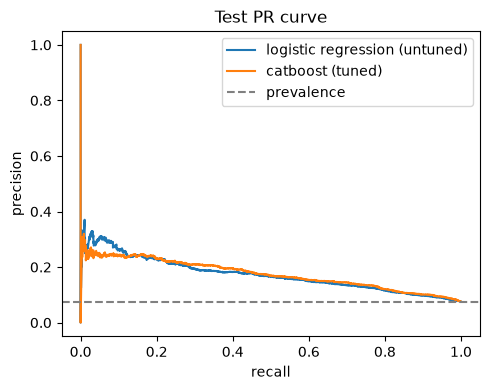

In [15]:
prec_tuned, rec_tuned, _ = precision_recall_curve(y_test, test_proba)

pipe_lr_ref = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)),
]).fit(X_train, y_train)
proba_lr_ref = pipe_lr_ref.predict_proba(X_test)[:, 1]
prec_lr, rec_lr, _ = precision_recall_curve(y_test, proba_lr_ref)

plt.figure(figsize=(5, 4))
plt.plot(rec_lr, prec_lr, label="logistic regression (untuned)")
plt.plot(rec_tuned, prec_tuned, label="catboost (tuned)")
plt.axhline(y_test.mean(), linestyle="--", color="gray", label="prevalence")
plt.xlabel("recall")
plt.ylabel("precision")
plt.title("Test PR curve")
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/tuned_models_pr_curve.png", dpi=100)
plt.show()

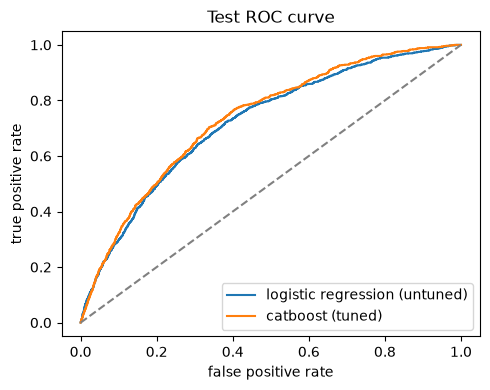

In [16]:
fpr_tuned, tpr_tuned, _ = roc_curve(y_test, test_proba)
fpr_lr, tpr_lr, _ = roc_curve(y_test, proba_lr_ref)

plt.figure(figsize=(5, 4))
plt.plot(fpr_lr, tpr_lr, label="logistic regression (untuned)")
plt.plot(fpr_tuned, tpr_tuned, label="catboost (tuned)")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.title("Test ROC curve")
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/tuned_models_roc_curve.png", dpi=100)
plt.show()

## Save final results

In [17]:
final_results = pd.DataFrame([
    {"model": "catboost", "tuned": True, "feature_set": "previous inspection + 365-day + 730-day history (15 features)",
     "val_pr_auc": overall_best["val_pr_auc"], "val_roc_auc": overall_best["val_roc_auc"], "threshold": best_t,
     "test_pr_auc": test_pr_auc, "test_roc_auc": test_roc_auc,
     "test_precision": test_precision, "test_recall": test_recall,
     "test_f1": test_f1, "test_accuracy": test_accuracy,
     "train_rows": len(train), "val_rows": len(val), "test_rows": len(test),
     "train_start": train["inspectionDate"].min(), "train_end": train["inspectionDate"].max(),
     "val_start": val["inspectionDate"].min(), "val_end": val["inspectionDate"].max(),
     "test_start": test["inspectionDate"].min(), "test_end": test["inspectionDate"].max()},
])
final_results.to_csv("../outputs/tuned_model_results.csv", index=False)
print("saved outputs/tuned_model_results.csv")

saved outputs/tuned_model_results.csv


## Interpretation

The Logistic Regression search barely moved (`C` had almost no effect on validation PR-AUC, ranging 0.1625 to 0.1632), which makes sense for a small, mostly-count feature set, regularization strength just doesn't matter much here. The CatBoost search was much more informative: deeper, longer-trained configurations clearly overfit relative to a shallow, short one, and choosing the shallow configuration (`depth=4, iterations=300`) using validation alone produced a model that also generalized better to test (PR-AUC 0.174, ROC-AUC 0.734), not just a model that looked better on validation. That's an important distinction, this wasn't a case of validation improving while test stayed flat or got worse, both moved together.

Against the previous best untuned result (Logistic Regression, test PR-AUC 0.173), the tuned CatBoost is only marginally ahead on PR-AUC but noticeably ahead on ROC-AUC (0.734 vs 0.720). This is a small, genuine improvement from tuning, not a dramatic one, and it came from correcting an overfit hyperparameter choice rather than from finding some clever new setting. As always, this remains prediction of the recorded DineSafe Non-Pass outcome, not a causal or safety claim.